# Regional Differences

In [7]:
%config InlineBackend.figure_format = 'svg'

Analysis complete. Found 6 significant regional differences.
Results saved to ./results/


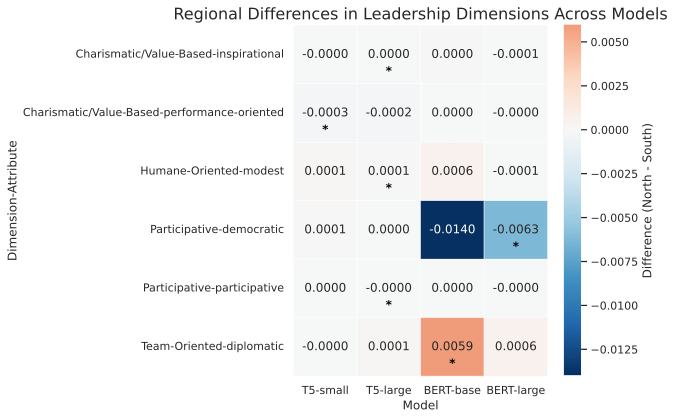

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Function to read and process data from each model
def load_model_data(filename):
    """Load and preprocess model data from CSV file."""
    df = pd.read_csv(filename)
    
    # Create a model identifier from the filename
    filepath = Path(filename)
    if "t5-small" in filename:
        model_name = "T5-small"
    elif "t5large" in filename:
        model_name = "T5-large"
    elif "bert_base" in filename:
        model_name = "BERT-base"
    elif "bert_large" in filename:
        model_name = "BERT-large"
    else:
        model_name = filepath.stem.split("_")[0]
    
    # Select only relevant columns
    result_df = df[['attribute', 'dimension', 'north_mean', 'south_mean', 
                    'diff', 'p_value', 'significant']]
    
    # Rename columns to include model name
    result_df = result_df.rename(columns={
        'north_mean': f'north_mean_{model_name}',
        'south_mean': f'south_mean_{model_name}',
        'diff': f'diff_{model_name}',
        'p_value': f'p_value_{model_name}',
        'significant': f'significant_{model_name}'
    })
    
    return result_df, model_name

# Function to merge data from all models
def merge_all_models(model_files):
    """Merge data from all models into a single dataframe."""
    combined_df = None
    model_names = []
    
    for file in model_files:
        df, model_name = load_model_data(file)
        model_names.append(model_name)
        
        if combined_df is None:
            combined_df = df
        else:
            # Merge on attribute and dimension
            combined_df = pd.merge(
                combined_df, df, on=['attribute', 'dimension'], how='outer'
            )
    
    return combined_df, model_names

# Filter for significant results in any model
def filter_significant_results(df, model_names, alpha=0.05):
    """Filter for attributes with significant results in any model."""
    sig_mask = False
    
    for model in model_names:
        sig_mask = sig_mask | (df[f'p_value_{model}'] < alpha)
    
    return df[sig_mask].sort_values(by='dimension')

# Create formatted table for the paper
def create_formatted_table(df, model_names):
    """Create a formatted table for the paper with all significant results."""
    # Create a table with the structure requested in the template
    table_data = []
    
    # Group by dimension
    grouped = df.groupby('dimension')
    
    for dimension, group in grouped:
        for _, row in group.iterrows():
            table_row = {
                'Leadership Dimension': dimension,
                'Attribute': row['attribute']
            }
            
            # Add data from each model
            for model in model_names:
                diff_val = row.get(f'diff_{model}', np.nan)
                p_val = row.get(f'p_value_{model}', np.nan)
                
                if not pd.isna(p_val) and p_val < 0.05:
                    # Format with asterisk for significance
                    diff_str = f"{diff_val:.4f}*"
                    p_str = f"{p_val:.3f}"
                else:
                    diff_str = f"{diff_val:.4f}" if not pd.isna(diff_val) else "-"
                    p_str = f"{p_val:.3f}" if not pd.isna(p_val) else "-"
                
                table_row[f'Diff (N-S)_{model}'] = diff_str
                table_row[f'p-value_{model}'] = p_str
            
            table_data.append(table_row)
    
    # Convert to DataFrame
    result_table = pd.DataFrame(table_data)
    
    # Reorder columns for better presentation
    col_order = ['Leadership Dimension', 'Attribute']
    for model in model_names:
        col_order.extend([f'Diff (N-S)_{model}', f'p-value_{model}'])
    
    return result_table[col_order]

# Create visualization for significant results
def create_visualization(df, model_names, output_file='figure1_regional_differences.png'):
    """Create a bar chart or heatmap of significant regional differences."""
    # Prepare data for plotting
    plot_data = []
    
    for _, row in df.iterrows():
        dimension = row['dimension']
        attribute = row['attribute']
        
        for model in model_names:
            diff_val = row.get(f'diff_{model}', np.nan)
            p_val = row.get(f'p_value_{model}', np.nan)
            
            if not pd.isna(p_val) and not pd.isna(diff_val):
                plot_data.append({
                    'Dimension': dimension,
                    'Attribute': attribute,
                    'Model': model,
                    'Difference (N-S)': diff_val,
                    'Significant': p_val < 0.05,
                    '-log10(p-value)': -np.log10(p_val) if p_val > 0 else 0
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    # Create a heatmap of differences
    plt.figure(figsize=(9, 6))
    
    # Define the desired order of models
    model_order = ['T5-small', 'T5-large', 'BERT-base', 'BERT-large']
    
    # Pivot data for heatmap
    heatmap_data = plot_df.pivot_table(
        index=['Dimension', 'Attribute'],
        columns='Model',
        values='Difference (N-S)',
        aggfunc='first'
    )
    
    # Sort by dimension and effect size
    heatmap_data = heatmap_data.sort_index(level=0)
    
    # Reorder the columns (models) in the heatmap data
    heatmap_data = heatmap_data[model_order]
    
    # Create the heatmap
    ax = sns.heatmap(
        heatmap_data, 
        cmap='RdBu_r',
        center=0,
        annot=True,
        fmt='.4f',
        linewidths=.5,
        cbar_kws={'label': 'Difference (North - South)'}
    )
    
    # Highlight significant values
    sig_mask = plot_df.pivot_table(
        index=['Dimension', 'Attribute'],
        columns='Model',
        values='Significant',
        aggfunc='first'
    )
    
    # Reorder the columns in significance mask to match heatmap_data
    sig_mask = sig_mask[model_order]
    
    # Add asterisks for significant values
    for i, idx in enumerate(heatmap_data.index):
        for j, col in enumerate(heatmap_data.columns):
            if sig_mask.loc[idx, col]:
                ax.text(j + 0.5, i + 0.85, '*', 
                        horizontalalignment='center', 
                        color='black', weight='bold', size=12)
    
    plt.title('Regional Differences in Leadership Dimensions Across Models', fontsize=16)
    plt.tight_layout()
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    
    return plot_df

# Generate dimension-by-dimension analysis
def generate_dimension_analysis(df, model_names):
    """Generate text analysis for each dimension with significant findings."""
    analysis_text = {}
    
    # Group by dimension
    grouped = df.groupby('dimension')
    
    for dimension, group in grouped:
        # Skip dimensions with no significant findings
        has_significant = False
        for model in model_names:
            if (group[f'p_value_{model}'] < 0.05).any():
                has_significant = True
                break
        
        if not has_significant:
            continue
            
        # Prepare analysis for this dimension
        attributes_with_sig = []
        
        for _, row in group.iterrows():
            attribute = row['attribute']
            sig_models = []
            
            for model in model_names:
                p_val = row.get(f'p_value_{model}', np.nan)
                diff_val = row.get(f'diff_{model}', np.nan)
                
                if not pd.isna(p_val) and p_val < 0.05:
                    direction = "stronger association with Global North" if diff_val > 0 else "stronger association with Global South"
                    sig_models.append(f"{model} (p = {p_val:.3f}, {direction})")
            
            if sig_models:
                attributes_with_sig.append(f"The '{attribute}' attribute demonstrated significant regional differences in {', '.join(sig_models)}.")
        
        if attributes_with_sig:
            # Create the analysis paragraph
            paragraph = f"{dimension} Leadership: This dimension showed notable regional variations. "
            paragraph += " ".join(attributes_with_sig)
            
            # Add pattern consistency across models
            consistent_pattern = True
            for attr in group['attribute'].unique():
                attr_group = group[group['attribute'] == attr]
                signs = []
                
                for model in model_names:
                    diff_col = f'diff_{model}'
                    if diff_col in attr_group.columns:
                        diff_val = attr_group[diff_col].values[0]
                        if not pd.isna(diff_val):
                            signs.append(np.sign(diff_val))
                
                if len(signs) > 1 and len(set(signs)) > 1:
                    consistent_pattern = False
                    break
            
            if consistent_pattern:
                paragraph += " This pattern was consistent across models where significant differences were observed."
            else:
                paragraph += " The direction of these regional associations varied across models, suggesting complex or model-dependent patterns."
            
            analysis_text[dimension] = paragraph
    
    return analysis_text

# Main analysis function
def analyze_regional_leadership_dimensions(model_files, output_dir='./', alpha=0.05):
    """Analyze regional variations in leadership dimensions across models."""
    # Create output directory if it doesn't exist
    Path(output_dir).mkdir(parents=True, exist_ok=True)
    
    # Load and merge data from all models
    combined_df, model_names = merge_all_models(model_files)
    
    # Filter for significant results
    significant_df = filter_significant_results(combined_df, model_names, alpha)
    
    # Create formatted table
    table = create_formatted_table(significant_df, model_names)
    table.to_csv(f"{output_dir}/table1_regional_leadership_dimensions.csv", index=False)
    
    # Create visualization
    visualization_df = create_visualization(
        significant_df, model_names, f"{output_dir}/figure1_regional_differences.png"
    )
    
    # Generate dimension-by-dimension analysis
    analysis_text = generate_dimension_analysis(significant_df, model_names)
    
    # Write analysis to file
    with open(f"{output_dir}/regional_dimension_analysis.txt", "w") as f:
        f.write("# Regional Variations in Leadership Dimensions\n\n")
        f.write("## Overview\n")
        f.write(f"Analysis revealed significant regional variations in {len(significant_df['dimension'].unique())} leadership dimensions ")
        f.write(f"across {len(model_names)} models. A total of {len(significant_df)} attribute-model combinations showed significant differences ")
        f.write(f"(p < {alpha}) between Global North and Global South contexts.\n\n")
        
        f.write("## Dimension-by-Dimension Analysis\n\n")
        for dimension, analysis in analysis_text.items():
            f.write(f"### {dimension}\n")
            f.write(f"{analysis}\n\n")
    
    return {
        'combined_data': combined_df,
        'significant_data': significant_df,
        'table': table,
        'visualization_data': visualization_df,
        'analysis_text': analysis_text,
        'model_names': model_names
    }

# Example usage
if __name__ == "__main__":
    # File paths provided by the user
    model_files = [
        "/data/########/facct/analysis_results_t5-small/region_ttest_results.csv",
        "/data/########/facct/analysis_results_t5large/region_ttest_results_t5large.csv",
        "/data/########/facct/analysis_results_bert_base_uncased/region_ttest_results_bert.csv",
        "/data/########/facct/analysis_results_bert_large_uncased/region_ttest_results_bert_large.csv"
    ]
    
    # You can change the output directory as needed
    results = analyze_regional_leadership_dimensions(model_files, output_dir='./leadership_results')
    
    # Print summary
    print(f"Analysis complete. Found {len(results['significant_data'])} significant regional differences.")
    print(f"Results saved to ./results/")

# Gender Differences

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# Function to read and process data from each model
def load_model_data(filename):
    """Load and preprocess model data from CSV file."""
    df = pd.read_csv(filename)
    
    # Create a model identifier from the filename
    filepath = Path(filename)
    if "t5-small" in filename:
        model_name = "T5-small"
    elif "t5large" in filename:
        model_name = "T5-large"
    elif "bert_base" in filename:
        model_name = "BERT-base"
    elif "bert_large" in filename:
        model_name = "BERT-large"
    else:
        model_name = filepath.stem.split("_")[0]
    
    # Select only relevant columns for gender analysis
    result_df = df[['attribute', 'dimension', 'male_mean', 'female_mean', 
                    'diff', 'p_value', 'significant']]
    
    # Rename columns to include model name
    result_df = result_df.rename(columns={
        'male_mean': f'male_mean_{model_name}',
        'female_mean': f'female_mean_{model_name}',
        'diff': f'diff_{model_name}',
        'p_value': f'p_value_{model_name}',
        'significant': f'significant_{model_name}'
    })
    
    return result_df, model_name

# Function to merge data from all models
def merge_all_models(model_files):
    """Merge data from all models into a single dataframe."""
    combined_df = None
    model_names = []
    
    for file in model_files:
        df, model_name = load_model_data(file)
        model_names.append(model_name)
        
        if combined_df is None:
            combined_df = df
        else:
            # Merge on attribute and dimension
            combined_df = pd.merge(
                combined_df, df, on=['attribute', 'dimension'], how='outer'
            )
    
    return combined_df, model_names

# Filter for significant results in any model
def filter_significant_results(df, model_names, alpha=0.05):
    """Filter for attributes with significant results in any model."""
    sig_mask = False
    
    for model in model_names:
        sig_col = f'significant_{model}'
        if sig_col in df.columns:
            sig_mask = sig_mask | df[sig_col]
        else:
            p_val_col = f'p_value_{model}'
            if p_val_col in df.columns:
                sig_mask = sig_mask | (df[p_val_col] < alpha)
    
    return df[sig_mask].sort_values(by='dimension')

# Create formatted table for the paper
def create_formatted_table(df, model_names):
    """Create a formatted table for the paper with all significant results."""
    # Create a table with the structure requested in the template
    table_data = []
    
    # Group by dimension
    grouped = df.groupby('dimension')
    
    for dimension, group in grouped:
        for _, row in group.iterrows():
            table_row = {
                'Leadership Dimension': dimension,
                'Attribute': row['attribute']
            }
            
            # Add data from each model
            for model in model_names:
                diff_val = row.get(f'diff_{model}', np.nan)
                p_val = row.get(f'p_value_{model}', np.nan)
                sig_val = row.get(f'significant_{model}', False)
                
                if not pd.isna(p_val) and (p_val < 0.05 or sig_val):
                    # Format with asterisk for significance
                    diff_str = f"{diff_val:.4f}*"
                    p_str = f"{p_val:.4f}"
                else:
                    diff_str = f"{diff_val:.4f}" if not pd.isna(diff_val) else "-"
                    p_str = f"{p_val:.4f}" if not pd.isna(p_val) else "-"
                
                table_row[f'Diff (M-F)_{model}'] = diff_str
                table_row[f'p-value_{model}'] = p_str
            
            table_data.append(table_row)
    
    # Convert to DataFrame
    result_table = pd.DataFrame(table_data)
    
    # Reorder columns for better presentation
    col_order = ['Leadership Dimension', 'Attribute']
    for model in model_names:
        col_order.extend([f'Diff (M-F)_{model}', f'p-value_{model}'])
    
    # Return only columns that exist in the dataframe
    existing_cols = [col for col in col_order if col in result_table.columns]
    return result_table[existing_cols]

# Function to generate the table for gender differences
def generate_gender_table(model_files, output_path=None):
    """Generate a formatted table of significant gender differences in leadership dimensions."""
    # Load and merge data from all models
    combined_df, model_names = merge_all_models(model_files)
    
    # Filter for significant results
    significant_df = filter_significant_results(combined_df, model_names)
    
    # Create formatted table
    table = create_formatted_table(significant_df, model_names)
    
    # Save table if output path is provided
    if output_path:
        table.to_csv(output_path, index=False)
        print(f"Table saved to {output_path}")
    
    return table

# Example usage
if __name__ == "__main__":
    # Replace these with your actual file paths
    model_files = [
        "/data/########/facct/analysis_results_t5-small/gender_ttest_results.csv",
        "/data/########/facct/analysis_results_t5large/gender_ttest_results_t5large.csv",
        "/data/########/facct/analysis_results_bert_base_uncased/gender_ttest_results_bert.csv",
        "/data/########/facct/analysis_results_bert_large_uncased/gender_ttest_results_bert_large.csv"
    ]
    
    # Generate the table
    table = generate_gender_table(model_files, "table2_gender_leadership_dimensions.csv")
    
    # Print the table
    print("\nTable 2: Significant Gender Differences in Leadership Dimensions\n")
    print(table.to_string())

Table saved to table2_gender_leadership_dimensions.csv

Table 2: Significant Gender Differences in Leadership Dimensions

       Leadership Dimension             Attribute Diff (M-F)_T5-small p-value_T5-small Diff (M-F)_T5-large p-value_T5-large Diff (M-F)_BERT-base p-value_BERT-base Diff (M-F)_BERT-large p-value_BERT-large
0                Autonomous       individualistic             0.0134*           0.0001            -0.0018*           0.0081               0.0005            0.2840                0.0005             0.0594
1                Autonomous            autonomous              0.0001           0.0611              0.0000           0.1212             -0.0052*            0.0113              -0.0085*             0.0005
2                Autonomous           independent            -0.0023*           0.0412              0.0000           0.6205             -0.0126*            0.0058               -0.0057             0.0534
3   Charismatic/Value-Based      self-sacrificial            -

Heatmap saved to figure2_gender_differences.png
Heatmap generated successfully with 22 significant attributes.


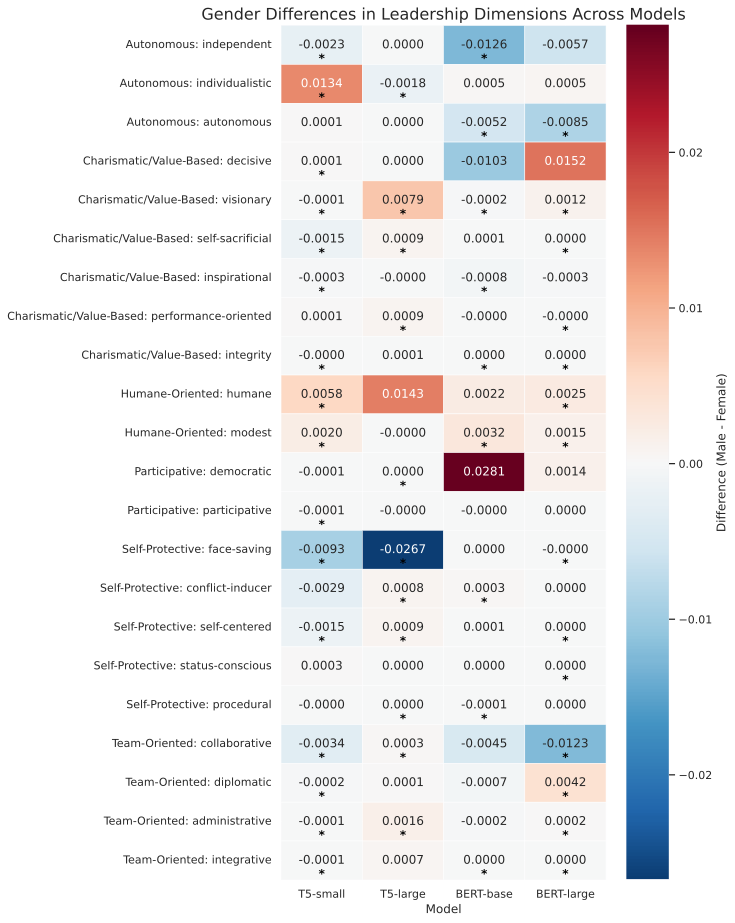

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Function to read and process data from each model
def load_model_data(filename):
    """Load and preprocess model data from CSV file."""
    df = pd.read_csv(filename)
    
    # Create a model identifier from the filename
    filepath = Path(filename)
    if "t5-small" in filename:
        model_name = "T5-small"
    elif "t5large" in filename:
        model_name = "T5-large"
    elif "bert_base" in filename:
        model_name = "BERT-base"
    elif "bert_large" in filename:
        model_name = "BERT-large"
    else:
        model_name = filepath.stem.split("_")[0]
    
    # Select only relevant columns for gender analysis
    result_df = df[['attribute', 'dimension', 'male_mean', 'female_mean', 
                    'diff', 'p_value', 'significant']]
    
    # Rename columns to include model name
    result_df = result_df.rename(columns={
        'male_mean': f'male_mean_{model_name}',
        'female_mean': f'female_mean_{model_name}',
        'diff': f'diff_{model_name}',
        'p_value': f'p_value_{model_name}',
        'significant': f'significant_{model_name}'
    })
    
    return result_df, model_name

# Function to merge data from all models
def merge_all_models(model_files):
    """Merge data from all models into a single dataframe."""
    combined_df = None
    model_names = []
    
    for file in model_files:
        df, model_name = load_model_data(file)
        model_names.append(model_name)
        
        if combined_df is None:
            combined_df = df
        else:
            # Merge on attribute and dimension
            combined_df = pd.merge(
                combined_df, df, on=['attribute', 'dimension'], how='outer'
            )
    
    return combined_df, model_names

# Filter for significant results in any model
def filter_significant_results(df, model_names, alpha=0.05):
    """Filter for attributes with significant results in any model."""
    sig_mask = False
    
    for model in model_names:
        sig_col = f'significant_{model}'
        if sig_col in df.columns:
            sig_mask = sig_mask | df[sig_col]
        else:
            p_val_col = f'p_value_{model}'
            if p_val_col in df.columns:
                sig_mask = sig_mask | (df[p_val_col] < alpha)
    
    return df[sig_mask].sort_values(by='dimension')

# Create visualization for significant gender differences
def create_gender_heatmap(df, model_names, output_file='figure2_gender_differences.png', alpha=0.05):
    """Create a heatmap of significant gender differences."""
    # Prepare data for plotting
    plot_data = []
    
    for _, row in df.iterrows():
        dimension = row['dimension']
        attribute = row['attribute']
        
        for model in model_names:
            diff_val = row.get(f'diff_{model}', np.nan)
            p_val = row.get(f'p_value_{model}', np.nan)
            sig_val = row.get(f'significant_{model}', False)
            
            is_significant = sig_val if not pd.isna(sig_val) else (not pd.isna(p_val) and p_val < alpha)
            
            if not pd.isna(diff_val):
                plot_data.append({
                    'Dimension': dimension,
                    'Attribute': attribute,
                    'Model': model,
                    'Difference (M-F)': diff_val,
                    'Significant': is_significant,
                    '-log10(p-value)': -np.log10(p_val) if not pd.isna(p_val) and p_val > 0 else 0
                })
    
    plot_df = pd.DataFrame(plot_data)
    
    if plot_df.empty:
        print("No data to visualize")
        return None
        
    # Create a heatmap of differences
    plt.figure(figsize=(10, len(df) * 0.5 + 2))  # Increased cell height to accommodate asterisks
    
    # Define the desired order of models
    model_order = [m for m in ['T5-small', 'T5-large', 'BERT-base', 'BERT-large'] if m in model_names]
    
    # Combine dimension and attribute for better labels
    plot_df['Label'] = plot_df['Dimension'] + ': ' + plot_df['Attribute']
    
    # Pivot data for heatmap
    heatmap_data = plot_df.pivot_table(
        index='Label',
        columns='Model',
        values='Difference (M-F)',
        aggfunc='first'
    )
    
    # Sort by dimension and then by average absolute effect size
    # First, compute average effect size for each attribute
    avg_effect = plot_df.groupby('Label')['Difference (M-F)'].apply(
        lambda x: np.abs(x).mean()
    ).sort_values(ascending=False)
    
    # Sort heatmap data by dimension, then by average effect size
    dimension_order = {}
    for idx, row in enumerate(plot_df['Label'].unique()):
        dimension = row.split(':')[0]
        if dimension not in dimension_order:
            dimension_order[dimension] = idx * 100  # Use a large multiplier to ensure dimensions stay together
    
    # Create a sorter series
    sorter = pd.Series({
        label: dimension_order[label.split(':')[0]] - avg_effect.get(label, 0)
        for label in heatmap_data.index
    })
    
    # Sort the heatmap data
    heatmap_data = heatmap_data.loc[sorter.sort_values().index]
    
    # Reorder the columns (models) in the heatmap data if needed
    existing_models = [m for m in model_order if m in heatmap_data.columns]
    if existing_models:
        heatmap_data = heatmap_data[existing_models]
    
    # Create the heatmap
    ax = sns.heatmap(
        heatmap_data, 
        cmap='RdBu_r',  # Red-Blue diverging colormap (red for positive, blue for negative)
        center=0,        # Center the colormap at zero
        annot=True,      # Show values
        fmt='.4f',       # Format for the values
        linewidths=.5,   # Grid lines
        cbar_kws={'label': 'Difference (Male - Female)'}
    )
    
    # Rotate y-axis labels for better readability
    plt.yticks(rotation=0)
    
    # Highlight significant values
    sig_mask = plot_df.pivot_table(
        index='Label',
        columns='Model',
        values='Significant',
        aggfunc='first'
    )
    
    # Make sure sig_mask has the same index and columns as heatmap_data
    sig_mask = sig_mask.reindex(index=heatmap_data.index, columns=heatmap_data.columns)
    
    # Add asterisks for significant values - positioned below the values to avoid overlap
    for i, idx in enumerate(heatmap_data.index):
        for j, col in enumerate(heatmap_data.columns):
            if idx in sig_mask.index and col in sig_mask.columns and sig_mask.loc[idx, col]:
                ax.text(j + 0.5, i + 0.95, '*', 
                        horizontalalignment='center', 
                        color='black', weight='bold', size=12)
    
    plt.title('Gender Differences in Leadership Dimensions Across Models', fontsize=16)
    plt.tight_layout()
    
    # Save figure
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"Heatmap saved to {output_file}")
    
    return plot_df

# Main function to generate the gender differences heatmap
def generate_gender_heatmap(model_files, output_file='figure2_gender_differences.png', alpha=0.05):
    """Generate a heatmap visualization of significant gender differences in leadership dimensions."""
    # Load and merge data from all models
    combined_df, model_names = merge_all_models(model_files)
    
    # Filter for significant results
    significant_df = filter_significant_results(combined_df, model_names, alpha)
    
    # Create visualization
    if not significant_df.empty:
        plot_df = create_gender_heatmap(significant_df, model_names, output_file, alpha)
        return {
            'significant_data': significant_df,
            'plot_data': plot_df
        }
    else:
        print("No significant gender differences found.")
        return None

# Example usage
if __name__ == "__main__":
    # Replace these with your actual file paths
    model_files = [
        "/data/########/facct/analysis_results_t5-small/gender_ttest_results.csv",
        "/data/########/facct/analysis_results_t5large/gender_ttest_results_t5large.csv",
        "/data/########/facct/analysis_results_bert_base_uncased/gender_ttest_results_bert.csv",
        "/data/########/facct/analysis_results_bert_large_uncased/gender_ttest_results_bert_large.csv"
    ]
    
    # Generate the heatmap
    results = generate_gender_heatmap(model_files, "figure2_gender_differences.png")
    
    if results:
        print(f"Heatmap generated successfully with {len(results['significant_data'])} significant attributes.")